In [22]:
import json
import math
import matplotlib.pyplot as plt

<h1> <center> Quantifying On-the-Ball Value in Football Using Expected Possession Modeling </center> </h1>
<br>
<h1> <center> Contents </center> </h1>
<br>
<h3><center> 1. Introduction </center></h3>
<h3><center> 2. Related Metrics </center></h3>
<h3><center> 3. Data Used </center></h3>
<h3><center> 4. Methodology </center></h3>
<h3><center> 5. Result </center></h3>
<h3><center> 6. Summary </center></h3>
<h3><center> 7. Conclusion </center></h3>

##### Author: Denislav Iliev

<h1><center> Introduction </center></h1>

In football, traditional performance statistics such as goals and assists continue to play a central role in player evaluation due to their intuitive and easily understandable nature. A high goal tally typically signals a prolific striker, while a large number of assists often highlights creative playmakers. However, these metrics fail to capture the full context in which actions occur.

For instance, a forward may receive consistently low-quality chances, limiting their scoring output despite intelligent movement and positioning. Vice versa, a player may accumulate goals that result from highly favorable circumstances rather than actual skill. Traditional counting statistics therefore struggle to isolate individual contribution from contextual factors.

This limitation has led to need of development for more advanced analytical frameworks, designed to evaluate the value of on-ball actions. One such approach is the On-the-Ball Value (*OBV*) model. OBV aims to assign a quantitative value to each action performed by a player, measuring its impact on the likelihood of the team scoring or conceding during a possession sequence.

Originally introduced by Hudl StatsBomb, OBV represents a modern attempt to evaluate football actions through expected possession modeling. By estimating how each pass, dribble, shot, or defensive action changes the value of a possession, the model provides a more precise and context-aware assessment of player's contribution.

Through this framework, it becomes possible to analyze:

* Change in scoring/cenceding probability - How each action increases/decreases the possibility of scoring or how it affects the chances of conceding.
  
* Possession Value - What is the net added value during a possession sequence.

* Action level impact -  The individual value of a passes, dribbles and shots.

* Risk–reward trade-offs in decision-making

The primary objective of this study is to build and evaluate an OBV-based framework using event-level data to quantify individual on-ball contributions.

<h1><center> Related Metrics </center></h1>

The evolution of football analytics inevitably led to the creation of more sophisticated metrics aimed at quantifying each player's contribution beyond the traditional counting statistics such as goals or assists. These new metrics attempt to evaluate the quality of goalscoring opportunities, the value of actions within possession or the impact a player has on the outcome of a match. One of the earliest and most influential metrics in this context is the **Expected Goals** (xG). Developed around early 2010s this metric is now widely implemented by data providers such as Opta and StatsBomb.

The primary purpose of the $ xG $ is to evaluate the probability of a shot to be converted into a goal. Even though there are several models to estimate the xG of a shot, the most common way to do it is with the following formula:
$$ xG_i = P(Y_i = 1 | X_i) $$

Where:

$ xG_i $ stands for the expected goal value of shot $ i $

$ Y \in$ {0, 1}, where 1 = goal and 0 = no goal

$ X_i $ stands for the features describing the shot $ i $, such as:

* Distance to goal
* Angle to goal
* Shot type (header, volley, deadball etc..)

As it is not the subject of this study, let's make the assumption that this model is working without proving it any further. Despite that this model is widely spread and indeed a very useful metric, it has one major flaw and that is the fact that it accounts only for a shot-specific characteristics without taking into consideration the context that lead to the final action such as but not limited to:

* The quality of the pass before the shot
* The defensive structure of the opposition
* The dribble that cracked the defense

To illustrate how xG can be analyzed, a single match from the publicly available StatsBomb Open Data repository is used. From this dataset, shot-level information is extracted, and shot distance is selected as one of the features. This allows for a visualization of the relationship between distnace and the estimated probability of scoring.

Event-level data used in this study were obtained from the publicly available StatsBomb Open Data repository. The dataset contains detailed event information including shot location, shot outcome, body part used, and the corresponding StatsBomb expected goals (xG) value. All open data (including the one used within this Project) can be found in the [statsbomb/open data-page](https://github.com/statsbomb/open-data).


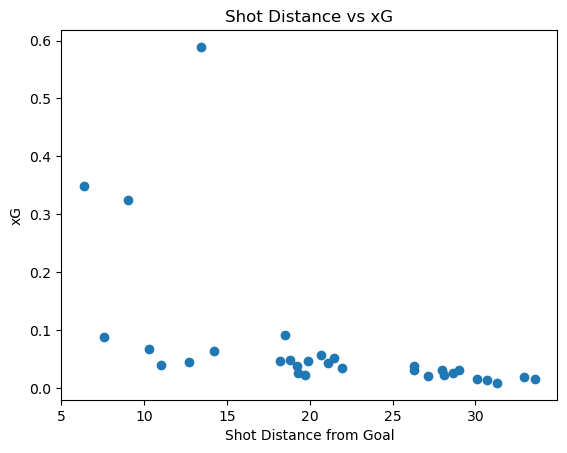

In [27]:
## Code
file_path = "3890560.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

shots = [event for event in data if event["type"]["name"] == "Shot"]

distances = []
xg_values = []

goal_x = 120
goal_y = 40

for shot in shots:
    location = shot.get("location")
    shot_xg = shot.get("shot", {}).get("statsbomb_xg")

    if location and shot_xg is not None:
        x, y = location
        distance = math.sqrt((goal_x - x)**2 + (goal_y - y)**2)
        
        distances.append(distance)
        xg_values.append(shot_xg)


plt.figure()
plt.scatter(distances, xg_values)

plt.xlabel("Shot Distance from Goal")
plt.ylabel("xG")
plt.title("Shot Distance vs xG")

plt.show()
        

The xG metric simply tells us: "The expected goal output for this particular shot from this distance in that particular case is this: ..."

The limitations of this model lead to the development of a new one that estimates a value for all on-ball actions in a possession sequence - $ Expected Threat $ ($ xT $)

Initially developed by Karun Singh in 2018, the ExpectedThreat model breaks down the football pitch into zones and assigns a *Threat* value to each, indicating the possibility of a goal to be scored from each zone.

In [28]:
# TO-DO next: Further explain xT
# Add formula and explain how it works
# Give showcase of the xT with viz
# Explain limitations
# Transition to OBV